## Imports

In [47]:
import os
import glob
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import librosa

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Fonction pour "écouter" un fichier et extraire une signature numérique

In [32]:
PATH_DATA = "../data"

def extraire_mfcc(chemin_fichier, n_mfcc=13):
    try:
        # duration=None permet de lire toute la piste, même si elle fait 1 seconde ou moins
        y, sr = librosa.load(chemin_fichier, duration=None, sr=None) 
        if len(y) == 0:
            return None
        # Extraction des MFCC
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        return None
    


## Scan automatique de l'arborescence

In [38]:
donnees_audio = []
labels_instruments = []
sources_dataset = []

print("Début du scan des dossiers et de l'extraction audio...")

Début du scan des dossiers et de l'extraction audio...


## Récupération des fichiers audios

In [39]:
extensions = ('/**/*.wav', '/**/*.mp3')
fichiers_audio = []
for ext in extensions:
    fichiers_audio.extend(glob.glob(PATH_DATA + ext, recursive=True))

print(f"{len(fichiers_audio)} fichiers audio détectés. Début de la correspondance avec les labels...")

23262 fichiers audio détectés. Début de la correspondance avec les labels...


### Boucle sur chaque fichier trouvé

In [40]:
for index, chemin_complet in enumerate(fichiers_audio):
    chemin_normalise = os.path.normpath(chemin_complet).replace('\\', '/')
    parties_chemin = chemin_normalise.split('/')
    
    # 1. Déterminer si c'est du Test IRMAS ou du Training/Philharmonia
    is_irmas_testing = "TestingData" in chemin_normalise
    
    instruments_du_fichier = []
    
    if is_irmas_testing:
        # --- CAS 1 : Testing IRMAS -> On lit le fichier .txt ---
        # On remplace l'extension audio par .txt
        chemin_txt = os.path.splitext(chemin_normalise)[0] + ".txt"
        
        if os.path.exists(chemin_txt):
            with open(chemin_txt, 'r') as f:
                # On nettoie chaque ligne du fichier texte (ex: "pia\n" devient "pia")
                instruments_du_fichier = [ligne.strip() for ligne in f.readlines() if ligne.strip()]
        else:
            continue # Si le fichier texte est introuvable, on passe au suivant
            
    else:
        # --- CAS 2 : Training IRMAS ou Philharmonia -> L'instrument est le nom du dossier ---
        instruments_du_fichier = [parties_chemin[-2]]
    
    # 2. Extraction des caractéristiques de l'onde sonore
    features = extraire_mfcc(chemin_normalise)
    
    if features is not None:
        dataset_source = "IRMAS" if "IRMAS" in chemin_normalise else "philarmonia"
        
        # Un fichier de test peut contenir plusieurs instruments (ex: piano ET violon)
        # On crée une ligne pour chaque instrument détecté
        for inst in instruments_du_fichier:
            donnees_audio.append(features)
            labels_instruments.append(inst)
            sources_dataset.append(dataset_source)

    # Barre de progression simplifiée pour te rassurer pendant l'attente
    if (index + 1) % 1000 == 0:
        print(f"{index + 1}/{len(fichiers_audio)} fichiers traités...")

1000/23262 fichiers traités...
2000/23262 fichiers traités...
3000/23262 fichiers traités...
4000/23262 fichiers traités...
5000/23262 fichiers traités...
6000/23262 fichiers traités...
7000/23262 fichiers traités...
8000/23262 fichiers traités...
9000/23262 fichiers traités...
10000/23262 fichiers traités...
11000/23262 fichiers traités...
12000/23262 fichiers traités...
13000/23262 fichiers traités...
14000/23262 fichiers traités...
15000/23262 fichiers traités...
16000/23262 fichiers traités...
17000/23262 fichiers traités...
18000/23262 fichiers traités...


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27976\2283570661.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(chemin_fichier, duration=None, sr=None)


19000/23262 fichiers traités...
20000/23262 fichiers traités...
21000/23262 fichiers traités...
22000/23262 fichiers traités...
23000/23262 fichiers traités...


## Conversion en structure de données pour le ML

In [41]:
X_audio = np.array(donnees_audio)
df_target = pd.DataFrame({
    'instrument': labels_instruments,
    'source': sources_dataset
})

print("Analyse et extraction terminées avec succès !")
print(f"Format final de la matrice X (pistes, caractéristiques) : {X_audio.shape}")
print(f"Nombre de lignes dans la cible y : {len(df_target)}")

Analyse et extraction terminées avec succès !
Format final de la matrice X (pistes, caractéristiques) : (25303, 13)
Nombre de lignes dans la cible y : 25303


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_audio)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_visu = pd.DataFrame(X_pca, columns=['Axe de timbre PCA 1', 'Axe de timbre PCA 2'])
df_visu['Cluster'] = clusters.astype(str)  # Conversion en texte pour avoir des couleurs distinctes
df_visu['Instrument_Réel'] = df_target['instrument'].values

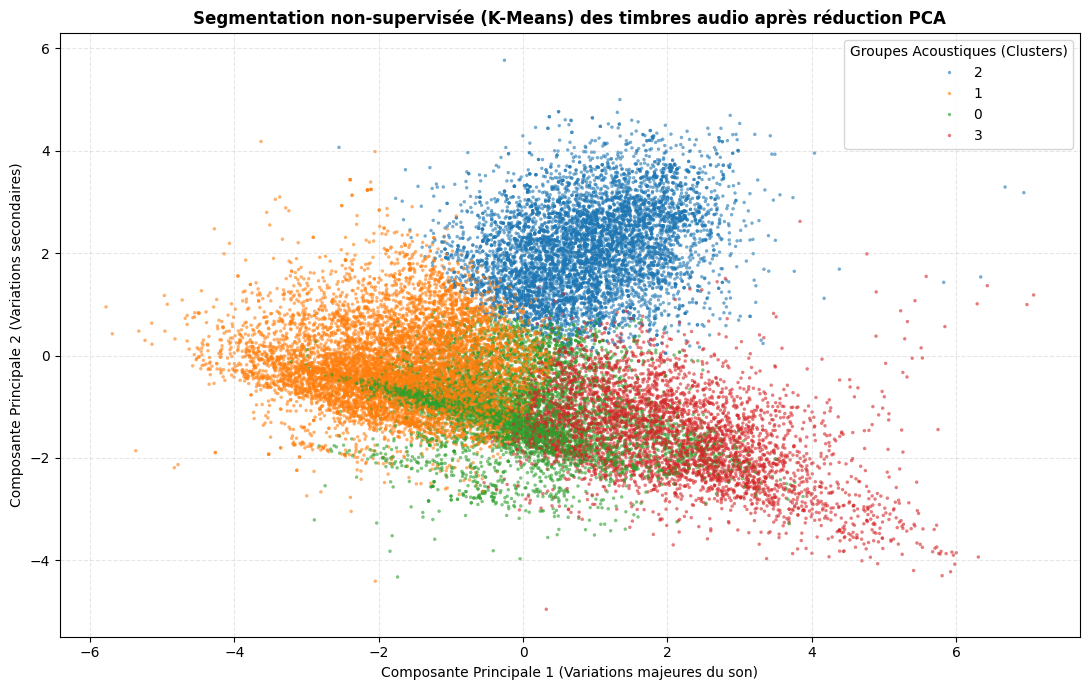

In [43]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    x='Axe de timbre PCA 1', 
    y='Axe de timbre PCA 2', 
    hue='Cluster', 
    data=df_visu, 
    palette='tab10',
    alpha=0.6,
    edgecolor=None,
    s=5  # Taille des points réduite car tu as 25 303 lignes !
)

plt.title("Segmentation non-supervisée (K-Means) des timbres audio après réduction PCA", fontsize=12, fontweight='bold')
plt.xlabel("Composante Principale 1 (Variations majeures du son)")
plt.ylabel("Composante Principale 2 (Variations secondaires)")
plt.legend(title="Groupes Acoustiques (Clusters)", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# Permet de voir quels instruments réels se cachent majoritairement dans chaque cluster
print(pd.crosstab(df_visu['Cluster'], df_visu['Instrument_Réel']))

Instrument_Réel  banjo  bass clarinet  bassoon  cel  cello  cla  clarinet  \
Cluster                                                                     
0                   16            276       22  113    432   63       111   
1                    4            470      645  249    311  335       320   
2                    0              0        8  134      3  149         1   
3                   54            198       45    3    143   20       414   

Instrument_Réel  contrabassoon  cor anglais  double bass  ...  sax  saxophone  \
Cluster                                                   ...                   
0                          509            6          809  ...   89         21   
1                          160          182           18  ...  366        432   
2                           41           23           22  ...  489         10   
3                            0          480            3  ...    8        269   

Instrument_Réel  trombone  tru  trumpet  tuba  vio

In [45]:
X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    X_audio, 
    df_target['instrument'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_target['instrument']
)

# 2. Normalisation : On "fit" sur le Train, et on "transform" le Train et le Test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entraînement du K-Means uniquement sur le jeu d'entraînement
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# 4. LA PRÉDICTION : On prédit les clusters sur le jeu de test (les données inconnues)
clusters_test_predits = kmeans.predict(X_test_scaled)

# %% [markdown]
# ## 6. Affichage des résultats de prédiction sur le jeu de Test

# %%
# Création d'un DataFrame pour analyser les prédictions du jeu de test
df_test_concret = pd.DataFrame({
    'Instrument_Réel': y_test_labels.values,
    'Cluster_Prédit': clusters_test_predits
})

# On affiche les 10 premières prédictions pour le rapport
print("=== Échantillon des prédictions sur le jeu de TEST ===")
print(df_test_concret.head(10))

=== Échantillon des prédictions sur le jeu de TEST ===
  Instrument_Réel  Cluster_Prédit
0             pia               2
1           viola               1
2            tuba               3
3             voi               0
4        trombone               2
5       saxophone               2
6          violin               1
7          violin               2
8             cel               2
9             pia               2


📊 Nombre d'échantillons retenus pour l'évaluation : 100 pia et 100 cel.

=== Nouvelles Performances (Sans Biais) ===
🎯 Accuracy réelle : 46.50%


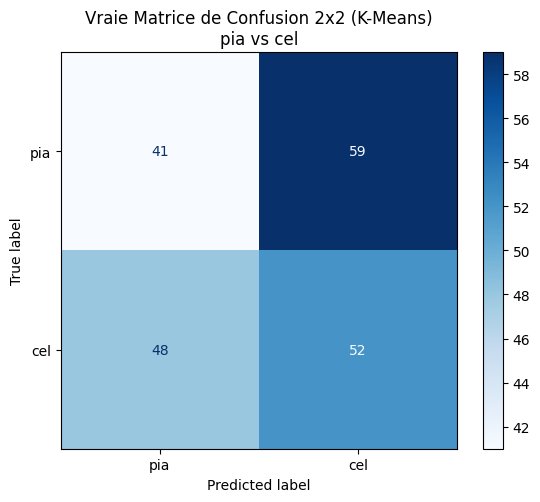

In [49]:
inst_A = 'pia'
inst_B = 'cel' # Tu peux tenter 'cel' (violoncelle), 'gac' (guitare acoustique) ou 'gel' (guitare élec) selon ton dossier

# On filtre le dataset de test pour n'avoir QUE ces deux instruments
df_brut_2x2 = df_test_concret[df_test_concret['Instrument_Réel'].isin([inst_A, inst_B])].copy()

# ÉQUILIBRAGE RAPIDE : On prend le même nombre de lignes pour les deux pour éviter le biais
min_samples = df_brut_2x2['Instrument_Réel'].value_counts().min()
df_binaire = df_brut_2x2.groupby('Instrument_Réel').sample(n=min_samples, random_state=42).reset_index(drop=True)

print(f"📊 Nombre d'échantillons retenus pour l'évaluation : {min_samples} {inst_A} et {min_samples} {inst_B}.")

# 2. MAPPING MANUEL ALIGNÉ SUR LES CLUSTERS
# On regarde quels sont les deux clusters les plus fréquents dans notre sélection
top_clusters = df_binaire['Cluster_Prédit'].value_counts().index[:2]

if len(top_clusters) < 2:
    print("❌ Les deux instruments sont mélangés dans le même unique cluster. Le K-Means ne les sépare pas.")
else:
    # On attribue le premier cluster au premier instrument, le second au deuxième
    mapping_clusters = {top_clusters[0]: inst_A, top_clusters[1]: inst_B}
    
    # On applique la traduction
    df_binaire['Instrument_Prédit'] = df_binaire['Cluster_Prédit'].map(mapping_clusters)
    
    # On remplace les clusters non traduits (s'il y en a) par l'inverse pour la matrice
    df_binaire['Instrument_Prédit'] = df_binaire['Instrument_Prédit'].fillna(inst_B)

    # 3. CALCUL DES MÉTRIQUES
    y_true = df_binaire['Instrument_Réel']
    y_pred = df_binaire['Instrument_Prédit']

    print("\n=== Nouvelles Performances (Sans Biais) ===")
    print(f"🎯 Accuracy réelle : {accuracy_score(y_true, y_pred):.2%}")

    # 4. AFFICHAGE 2x2
    cm_unsupervised = confusion_matrix(y_true, y_pred, labels=[inst_A, inst_B])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_unsupervised, display_labels=[inst_A, inst_B])
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f"Vraie Matrice de Confusion 2x2 (K-Means)\n{inst_A} vs {inst_B}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [50]:
centres_de_clusters = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=[f"MFCC {i}" for i in range(X_audio.shape[1])]
)
print("=== Profil acoustique moyen de chaque cluster (Centres) ===")
print(centres_de_clusters.head())

=== Profil acoustique moyen de chaque cluster (Centres) ===
     MFCC 0    MFCC 1    MFCC 2    MFCC 3    MFCC 4    MFCC 5    MFCC 6  \
0  1.284172  0.092020 -0.511058  1.008781 -0.651451  0.918072 -0.539748   
1 -0.949521 -1.305322 -0.432326 -0.837588 -0.301238 -0.386269  0.350178   
2 -0.267792  0.427116 -0.036619 -0.569840 -0.013024 -0.729085 -0.363573   
3 -0.403438  0.265824  1.042450  0.325960  1.073477  0.325506  0.962394   

     MFCC 7    MFCC 8    MFCC 9   MFCC 10   MFCC 11   MFCC 12  
0  0.748985 -0.246349  0.355070 -0.124206  0.259755 -0.039668  
1  0.364474  0.689957  0.902545  1.036376  0.963970  0.856563  
2 -0.796577 -0.504973 -0.689985 -0.483703 -0.601138 -0.402242  
3  0.035054  0.546806 -0.079511  0.081225 -0.151360 -0.007215  
